# Проект. Исследование стартапов

В нашем распоряжении исторические данные о стартапах, объёмах и типах финансирования, а также статистика возвратов средств. Нашей главной задачей является проведение исследовательского анализа для финансовой компании, работающей с венчурными инвестициями, чтобы оценить перспективы выхода на рынок с покупкой и развитием компаний.

## Шаг 1. Загрузка данных

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Считаем все необходимые CSV-файлы и сохраним их в датафреймы

In [2]:
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
re_df = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [5]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"

    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='Greys'))
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
name,4857,0.0895
homepage_url,8305,0.1530
category_list,8817,0.1624
market,8817,0.1624
funding_total_usd,4856,0.0894
status,6170,0.1136
country_code,10129,0.1866
state_code,24133,0.4445
region,10129,0.1866
city,10972,0.2021


In [7]:
re_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [8]:
re_df.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [9]:
show_missing_stats(re_df)

'Пропусков в данных нет'

In [10]:
temp = df.copy() 
len(temp)

54294

****Вывод:****

Датасет `cb_investments.zip` содержит 40 столбцов и 54294 строк, в которых представлена информация о компаниях и состоявшемся финансировании.

*Числовые значения с плавающей запятой (float64).* 24 столбца имеют тип данных float64:
`funding_rounds`, `participants` - рекомендуется перевести в int, т.к. количество раундов и участников - целочисленные показатели по смыслу.
Остальные столбцы с информацией о сумме инвестиции, тип данных подходит.

*Строковые данные (object).* 16 столбцов имеют тип данных object:`name`, `homepage_url`, `category_list`,`market`, `status`, `country_code`, `state_code`, `region`, `city` -  эти столбцы содержат строковую информацию, что логично для текстовых данных. Здесь тип данных object подходит.
`funding_total_usd` - объём инвестиций, поэтому преобразуем в числовое значение (float64).
`founded_at`, `founded_month`, `founded_quarter`, `first_funding_at`, `mid_funding_at`, `last_funding_at` - значения даты и времени, рекомендуется поменять на datetime.

Пропуски содержатся во всех столбцах.

Значения в столбцах соответствуют своему описанию.

Датасет `cb_returns` содержит 14 столбцов и 15 строк, в которых представлена информация об объёмах возвратов по годам и типам финансирования в миллионах долларов.

*Числовые значения (int64).* Один столбец имеет тип данных int64:
`year` - год возврата средств, тип данных подходит.

*Числовые значения с плавающей запятой (float64).* Оставшиеся 13 столбцов имеют тип данных float64:
с информацией о сумме возвратов от разных источников, тип данных подходит.

Пропусков нет.

Значения в столбцах соответствуют своему описанию. 

**1.2. Предобработка данных**

In [11]:
print('Названия столбцов датасета cb_investments.zip:', df.columns)
print('Названия столбцов датасета cb_returns:', re_df.columns)

Названия столбцов датасета cb_investments.zip: Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')
Названия столбцов датасета cb_returns: Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdf

Названия столбцов достаточно точно отражают содержимое данных и оформлены в удобном для работы стиле (snake case). В названиях двух столбцов есть пропуски, исправим это. 

In [12]:
df.columns = df.columns.str.strip()
print('Названия столбцов в датасета cb_investments.zip:', df.columns)

Названия столбцов в датасета cb_investments.zip: Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')


In [13]:
df['funding_total_usd'] = df['funding_total_usd'].str.replace(',', '')
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')
df['funding_total_usd'].head()

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
Name: funding_total_usd, dtype: float64

In [14]:
df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')
print(df['founded_at'].head(3))

0          NaT
1   1785-01-01
2   1802-07-19
Name: founded_at, dtype: datetime64[ns]


In [15]:
df['first_funding_at'] = pd.to_datetime(df['first_funding_at'], errors='coerce')
print(df['first_funding_at'].head())

0   2014-01-06
1   2014-05-15
2   2009-07-02
3   2013-11-21
4   2014-01-14
Name: first_funding_at, dtype: datetime64[ns]


In [16]:
df['mid_funding_at'] = pd.to_datetime(df['mid_funding_at'], errors='coerce')
print(df['mid_funding_at'].head(3))

0          NaT
1          NaT
2   2009-07-02
Name: mid_funding_at, dtype: datetime64[ns]


In [17]:
df['last_funding_at'] = pd.to_datetime(df['last_funding_at'], errors='coerce')
print(df['last_funding_at'].head(3))

0   2014-01-06
1   2014-05-15
2   2009-07-02
Name: last_funding_at, dtype: datetime64[ns]


In [18]:
#df = df.dropna(subset=['founded_year'])
#df['founded_year'] = df['founded_year'].astype(int)
#print(df['founded_year'].head(3))

In [19]:
#a, b = len(temp), len(df['founded_year'])
#print(" Было строк в исходном датасете", a,
      #'\n', "Осталось строк в датасете после обработки", b,
     #'\n', "Удалено строк в датасете после обработки", a-b,
     #'\n', "Процент потерь", round((a-b)/a*100, 2))

In [20]:
df['founded_year'] = pd.to_numeric(df['founded_year'])
df['founded_year'].head(3)

0    1636.0
1    1785.0
2    1802.0
Name: founded_year, dtype: float64

In [21]:
re_df = re_df.set_index('year')

Обрабатываем текстовые данные.

In [22]:
df['market'] = df['market'].str.lower().str.strip().str.replace(' ', '_')
df['market'].nunique()

439

In [23]:
df['name'] = df['name'].str.lower().str.strip().str.replace(' ', '_')
df['name'].nunique()

49330

In [24]:
print('Количество явных дубликатов:', df.duplicated().sum())
print('Доля дубликатов:', (df.duplicated().sum()/len(df))*100)
df = df.drop_duplicates()

Количество явных дубликатов: 4855
Доля дубликатов: 8.942056212472833


In [25]:
df = df.dropna(subset=['funding_total_usd'])
df = df[df['funding_total_usd'] > 0] 

df = df.dropna(subset=['name'])

Заполняем пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков берем приблизительно середину интервала между этими двумя датами.

In [26]:
def calculate_mid_date(row):
    time_diff = row['last_funding_at'] - row['first_funding_at']
    return row['first_funding_at'] + time_diff / 2

df['mid_funding_at'] = df.apply(calculate_mid_date, axis=1)
df['mid_funding_at'].head()

0   2014-01-06 00:00:00
1   2014-05-15 00:00:00
2   2009-07-02 00:00:00
3   2014-05-13 12:00:00
4   2014-01-14 00:00:00
Name: mid_funding_at, dtype: datetime64[ns]

In [27]:
missing_count = df['mid_funding_at'].isna().sum()
missing_percentage = (missing_count / len(df)) * 100

print(f"Пропуски: {missing_count}")
print(f"Процент: {(missing_percentage).round(2)}%")

Пропуски: 2
Процент: 0.0%


In [28]:
a, b = len(temp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 54294 
 Осталось строк в датасете после обработки 40906 
 Удалено строк в датасете после обработки 13388 
 Процент потерь 24.66


Потеряли 25% данных, но оставшихся 40906  компаний достаточно для анализа. Отсев в основном пришелся на некорректные или неполные записи. 

**Шаг 2. Инжиниринг признаков**

### 2.1. Группы по срокам финансирования

Разделяем все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализирем соотношение этих групп, создав два графика:

* По количеству компаний: какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: какую долю от общего объёма привлечённых средств получила каждая группа.

In [29]:
df['funding_duration'] = (df['last_funding_at'] - df['first_funding_at']).dt.days

def funding_durations(row):
    if (row['first_funding_at'] == row['last_funding_at']):
        return 'Единичное финансирование'
    elif row['funding_duration'] <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

df['group_funding_at'] = df.apply(funding_durations, axis=1)
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,funding_duration,group_funding_at
0,harvard_university,http://harvard.edu,|Education|,education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
1,university_of_new_brunswick,http://www.unb.ca,NaN,NaN,2000000.0,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
2,dupont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,business_services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
3,university_of_michigan,http://www.umich.edu/,|Education|,education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,347.0,Срок финансирования до года
4,case_western_reserve_university,http://www.case.edu,|Education|,education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование


In [30]:
group_counts = df['group_funding_at'].value_counts()
group_per = group_counts/df.shape[0]
group_df = pd.DataFrame({'Количество': group_counts, 'Процент': (group_per*100).round(1)})
print("Количество компаний по группам финансирования:")
print(group_df)

Количество компаний по группам финансирования:
                                Количество  Процент
Единичное финансирование             24288     59.4
Срок финансирования более года       12293     30.1
Срок финансирования до года           4325     10.6


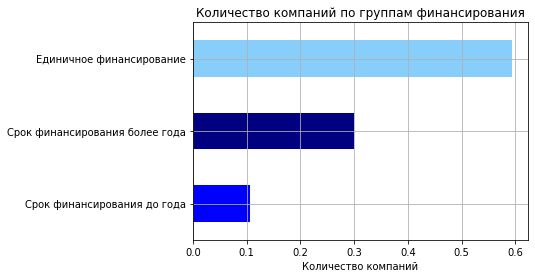

In [31]:
group_per.sort_values().plot(kind='barh', color=['blue', 'navy', 'lightskyblue']) #я так и не поняла, как каждой категории присвоить свой цвет
plt.title('Количество компаний по группам финансирования')
plt.xlabel('Количество компаний')

plt.grid()
plt.show()

Больше половины компаний (59,4 %) выбирают `разовое финансирование` - быстрое размещение капитала с минимальными рисками, но с ограниченной доходностью.  
Большинство (30,1 %) предпочитают `долгосрочное финансирование` -  стратегические вложения с отсроченной, но максимальной прибылью при управляемых рисках.  
Небольшая часть (10,6 %) использует `краткосрочное финансирование`- активный оборот капитала с высокими рисками для получения быстрой спекулятивной прибыли.   

In [32]:
group_funding = df.groupby('group_funding_at')['funding_total_usd'].sum()
group_funding_total = (df.groupby('group_funding_at')['funding_total_usd'].sum())/df['funding_total_usd'].sum()
group_funding_df = pd.DataFrame({'Количество': group_funding, 'Процент': (group_funding_total*100).round(1)})
print("Объём инвестиций по группам финансирования:")
print(group_funding_df)

Объём инвестиций по группам финансирования:
                                  Количество  Процент
group_funding_at                                     
Единичное финансирование        2.013224e+11     30.9
Срок финансирования более года  4.027433e+11     61.9
Срок финансирования до года     4.686800e+10      7.2


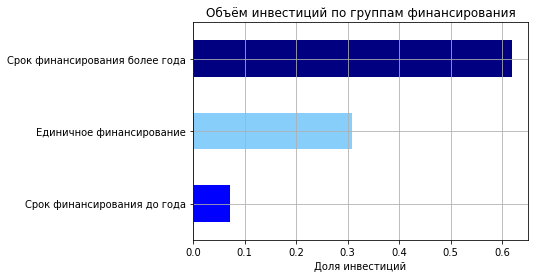

In [33]:
group_funding_total.sort_values().plot(kind='barh', color=['blue','lightskyblue', 'navy'])
plt.title('Объём инвестиций по группам финансирования')
plt.xlabel('Доля инвестиций')
plt.ylabel('')

plt.grid()
plt.show()

Долгосрочное финансирование (61,9 %) - долгие проекты требуют значительных финансов.  
Единичное финансирование (30,9 %) - много небольших сделок с умеренным финансированием.  
Краткосрочное финансирование (7,2 %) - маленькая доля рынка по объему капитала.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесим к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесим к средним, а сегменты до 35 компаний отнесим к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Строим график распределения количества компаний в сегментах.

In [34]:
market_counts = df['market'].value_counts()
print(market_counts)

software         4812
biotechnology    3590
mobile           2344
e-commerce       1866
curated_web      1693
                 ... 
gold                1
parking             1
portals             1
religion            1
cad                 1
Name: market, Length: 394, dtype: int64


In [35]:
def segments(count):
    if count > 120:
        return 'массовый'
    elif count < 35:
        return 'нишевый'
    else:
        return 'средний'

segment_categories = market_counts.apply(segments)
print(segment_categories)

software         массовый
biotechnology    массовый
mobile           массовый
e-commerce       массовый
curated_web      массовый
                   ...   
gold              нишевый
parking           нишевый
portals           нишевый
religion          нишевый
cad               нишевый
Name: market, Length: 394, dtype: object


In [36]:
print("Количество сегментов рынка в каждой категорий:")
segment_categories_counts = segment_categories.value_counts()
total_segments = len(segment_categories)

for category, count in segment_categories_counts.items():
    share = (count / total_segments * 100)
    print(f"{category}: {count} сегментов ({share}%)")

Количество сегментов рынка в каждой категорий:
нишевый: 289 сегментов (73.3502538071066%)
средний: 57 сегментов (14.467005076142131%)
массовый: 48 сегментов (12.18274111675127%)


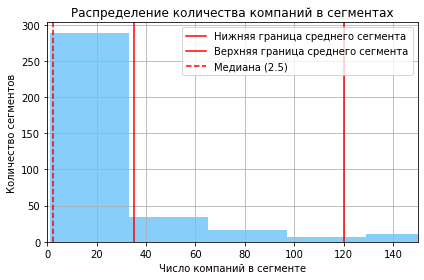

In [63]:
median_value = market_counts.median()

plt.hist(market_counts.values, bins=150, color ='lightskyblue')

plt.axvline(x=35, color='red', linestyle='-', label='Нижняя граница среднего сегмента')
plt.axvline(x=120, color='red', linestyle='-', label='Верхняя граница среднего сегмента')
plt.axvline(x=median_value, color='red', linestyle='--', label=f'Медиана ({median_value:.1f})')

plt.xlabel('Число компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.title('Распределение количества компаний в сегментах')
plt.gca().set_xlim(left=0, right=150)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Большая часть сегментов относится к нишевым. 

Оставляем в столбце `market` только массовые сегменты. Для остальных сегментов заменяем значения на заглушки — `niche` для нишевых и `mid` для средних.

In [38]:
market_counts = df['market'].value_counts()

def categorize_segment(segment):
    if pd.isna(segment):
        return 'niche'
    count = market_counts[segment]
    if count > 120:
        return segment
    elif count >= 35:
        return 'mid'
    else:
        return 'niche'

df['market'] = df['market'].apply(categorize_segment)

print(df['market'].value_counts())

software                4812
mid                     3841
biotechnology           3590
niche                   3333
mobile                  2344
e-commerce              1866
curated_web             1693
enterprise_software     1381
health_care             1185
clean_technology        1180
games                   1117
advertising             1107
hardware_+_software     1062
social_media            1003
health_and_wellness      873
education                844
finance                  828
analytics                667
manufacturing            596
security                 567
semiconductors           484
web_hosting              424
consulting               349
hospitality              336
travel                   330
fashion                  303
news                     301
messaging                295
search                   291
real_estate              279
saas                     272
music                    264
internet                 241
technology               238
apps          

71% сегментов - нишевые, 12% - массовые, хотя в массовых сегментах сосредоточено основное количество компаний.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцениваем, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. 

In [39]:
print("Общая статистика финансирования:")
print(df['funding_total_usd'].describe())

Общая статистика финансирования:
count    4.090600e+04
mean     1.591291e+07
std      1.686808e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64


На основе статистики определяем интервал типичных значений: от 300000 до 7500000$.   

Типичный размер общего финансирования для одной компании - 1664558$. 

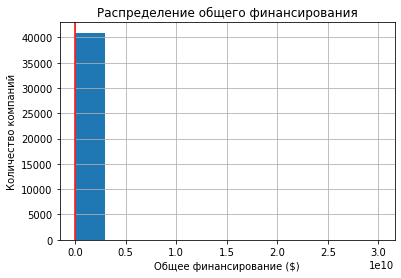

In [40]:
plt.hist(df['funding_total_usd'])
plt.axvline(df['funding_total_usd'].median(), color='red', linestyle='-')
plt.title('Распределение общего финансирования')
plt.xlabel('Общее финансирование ($)')
plt.ylabel('Количество компаний')
plt.grid()
plt.show()

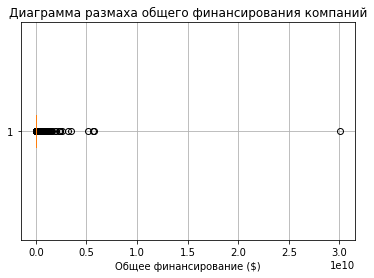

In [41]:
plt.boxplot(df['funding_total_usd'], vert=False)
plt.title('Диаграмма размаха общего финансирования компаний')
plt.xlabel('Общее финансирование ($)')
plt.grid()
plt.show()

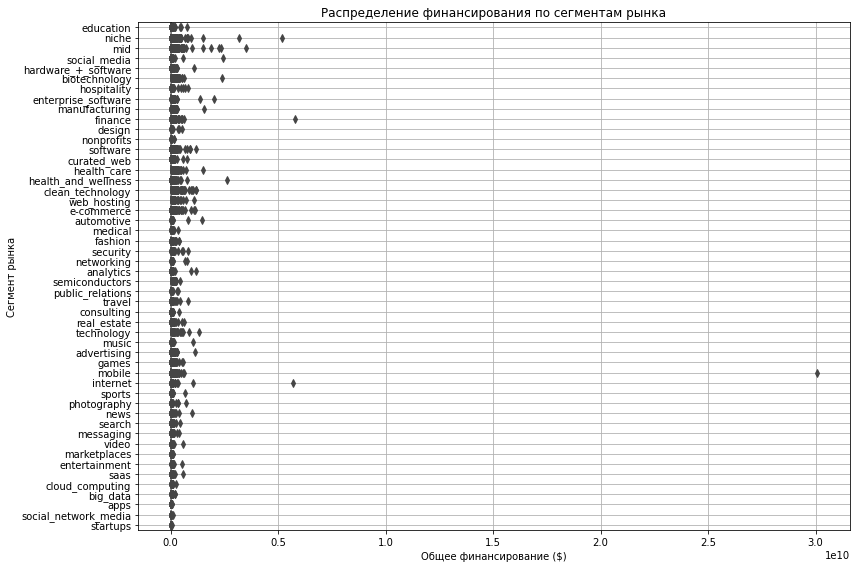

In [42]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='funding_total_usd', 
                y='market', 
                data=df,
                )

plt.title('Распределение финансирования по сегментам рынка')
plt.xlabel('Общее финансирование ($)')
plt.ylabel('Сегмент рынка')
plt.grid()

plt.tight_layout()
plt.show()

Определяем компании с аномальным объёмом общего финансирования, с помощью метода IQR отдельно по каждому сегменту.

Определяем сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование.

In [43]:
ratios = []

for segment, segment_data in df.groupby('market')['funding_total_usd']:
    Q1 = segment_data.quantile(0.25)
    Q3 = segment_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    

    outliers_count = len(df[(df['market'] == segment) & 
                           ((df['funding_total_usd'] > upper_bound) | 
                            (df['funding_total_usd'] < lower_bound))])
    
    total_companies = len(segment_data)
    outliers_ratio = outliers_count / total_companies if total_companies > 0 else 0
    
    ratios.append((outliers_ratio, segment, total_companies, outliers_count))

ratios.sort(reverse=True)
print("Топ сегментов рынка с наибольшей долей выбросов:")
print(f"{'Сегмент':25} {'Компаний':>10} {'Выбросов':>10} {'Доля':>10}")
for ratio, segment, total, outliers in ratios [:5]: 
    print(f"{segment:25} {total:10} {outliers:10} {ratio:9.1%}")

Топ сегментов рынка с наибольшей долей выбросов:
Сегмент                     Компаний   Выбросов       Доля
real_estate                      279         48     17.2%
entertainment                    150         25     16.7%
consulting                       349         58     16.6%
search                           291         48     16.5%
cloud_computing                  152         25     16.4%


Сегменты с наибольшей долей компаний, получивших аномально высокое финансирование `cloud_computing `, `photography` и `real_estate`  - по 17 %. 

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверяем по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. Затем исключаем из датасета компании, которые мы ранее посчитали получившими аномальное финансирование. После оставляем в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [44]:
filtered_df =df[df['founded_at'].dt.year == 2014]
print(f"Компаний с датой основания в 2014: {len(filtered_df)}")
months_2014 = filtered_df['founded_month'].value_counts()
print("Распределение по месяцам:")
print(months_2014)
quarters_2014 = filtered_df['founded_quarter'].value_counts()
print("Распределение по кварталам:")
print(quarters_2014)

Компаний с датой основания в 2014: 1015
Распределение по месяцам:
2014-01    414
2014-03    115
2014-02    110
2014-04     98
2014-05     81
2014-06     73
2014-07     46
2014-08     31
2014-09     26
2014-10     16
2014-11      3
2014-12      2
Name: founded_month, dtype: int64
Распределение по кварталам:
2014-Q1    639
2014-Q2    252
2014-Q3    103
2014-Q4     21
Name: founded_quarter, dtype: int64


In [45]:
df_size = len(df)
df = df[(df['funding_total_usd'] >= lower_bound) & (df['funding_total_usd'] <= upper_bound)]
clean = df_size - len(df)

print(f"Удалено компаний с аномальным финансированием: {clean}")
print(f"Осталось компаний: {len(df)}")

Удалено компаний с аномальным финансированием: 2068
Осталось компаний: 38838


In [46]:
actual_rounds = df.groupby(df['mid_funding_at'].dt.year)['funding_rounds'].sum()
actual_rounds_50 = actual_rounds[actual_rounds >= 50].index
df = df[df['mid_funding_at'].dt.year.isin(actual_rounds_50)]
print(actual_rounds_50)
print(df.shape[0])
df.head(3)

Float64Index([2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0,
              2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0],
             dtype='float64', name='mid_funding_at')
38757


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,funding_duration,group_funding_at
1,university_of_new_brunswick,http://www.unb.ca,NaN,niche,2000000.0,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
2,dupont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
3,university_of_michigan,http://www.umich.edu/,|Education|,education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,347.0,Срок финансирования до года


Данные за 2014 год содержат все месяцы и кварталы, но их нельзя назвать полными, т.к. есть спад к концу года: с 414 компаний в январе до 2 в декабре.     
После фильтрации осталось 38757 компании, получавшие финансирование в годы с высокой инвестиционной активностью (50+ раундов): 2000-2014 гг.

### 3.3. Анализ типов финансирования по объёму и популярности

Строим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег и график, который покажет популярность разных типов финансирования.

Сравниваем графики и выделяем часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

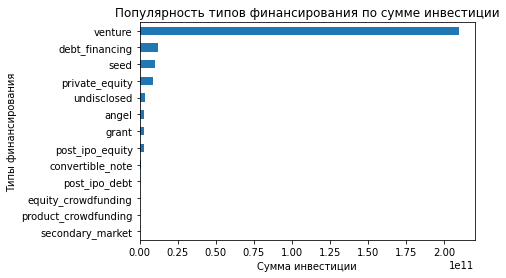

In [47]:
funding_columns = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                  'convertible_note', 'debt_financing', 'angel', 'grant', 
                  'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                  'secondary_market', 'product_crowdfunding']

funding_total = df[funding_columns].sum().sort_values()

funding_total.plot(kind='barh')
plt.title('Популярность типов финансирования по сумме инвестиции')
plt.xlabel('Сумма инвестиции')
plt.ylabel('Типы финансирования')

plt.show()

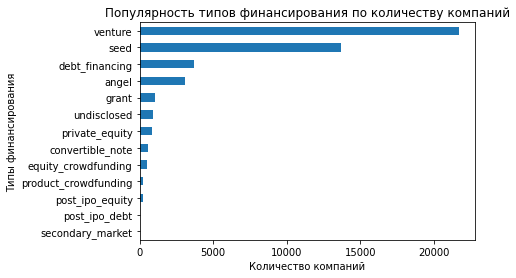

In [48]:
funding_counts = (df[funding_columns] != 0).sum().sort_values()


funding_counts.plot(kind='barh')
plt.title('Популярность типов финансирования по количеству компаний')
plt.xlabel('Количество компаний')
plt.ylabel('Типы финансирования')

plt.show()

Венчурные инвестиции - лидирует и по сумме, и по количеству компании.

Строим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

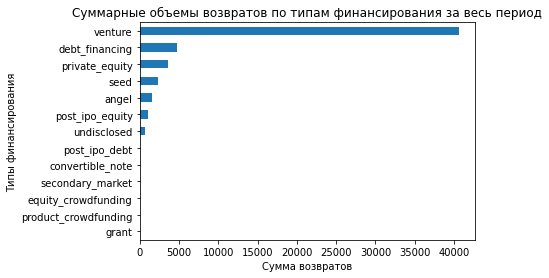

In [49]:
return_columns = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                 'convertible_note', 'debt_financing', 'angel', 'grant', 
                 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                 'secondary_market', 'product_crowdfunding']

return_total = re_df[return_columns].sum().sort_values()

return_total.plot(kind='barh')
plt.title('Суммарные объемы возвратов по типам финансирования за весь период')
plt.xlabel('Сумма возвратов')
plt.ylabel('Типы финансирования')

plt.show()

In [50]:
return_per = (return_total / return_total.sum())
return_df = pd.DataFrame({'Количество': return_total, 'Процент': (return_per)*100})
print("Количество компаний по группам финансирования:")
print(return_df)

Количество компаний по группам финансирования:
                      Количество    Процент
grant                       0.00   0.000000
product_crowdfunding        1.86   0.003396
equity_crowdfunding         3.83   0.006994
secondary_market            5.20   0.009495
convertible_note           34.79   0.063526
post_ipo_debt              91.03   0.166220
undisclosed               730.88   1.334579
post_ipo_equity          1104.96   2.017646
angel                    1509.23   2.755839
seed                     2382.24   4.349946
private_equity           3587.33   6.550428
debt_financing           4734.85   8.645788
venture                 40578.62  74.096144


Больше всего сумма возвратов от венчурных инвестиций - 74%. Все остальные типы финансирования вместе дали 26% возвратов, из которых сумма возвратов от долгового финансирования составляет 8,6% и сумма возвратов частных вложений - 6,6%. Гранты являются единственным типом финансирования с нулевым возвратом.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы строим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

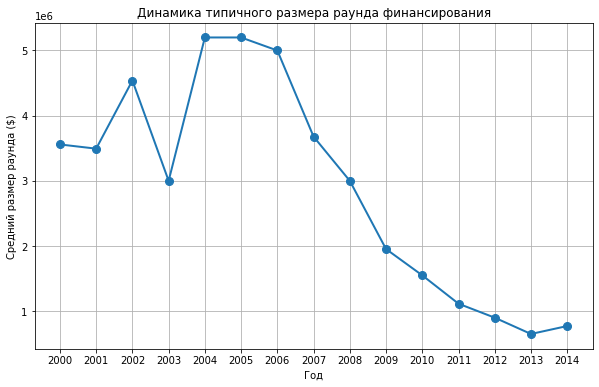

In [51]:
df['avg_round_amount'] = df['funding_total_usd'] / df['funding_rounds']
rounds_by_year = df.groupby(df['mid_funding_at'].dt.year)['funding_rounds'].sum()
plt.figure(figsize=(10, 6))
avg_round_by_year = df.groupby(df['mid_funding_at'].dt.year)['avg_round_amount'].median()
avg_round_by_year.plot(kind='line',
                       marker='o', 
                       linewidth=2, 
                       markersize=8)
plt.title('Динамика типичного размера раунда финансирования')
plt.xlabel('Год')
plt.ylabel('Средний размер раунда ($)')
plt.xticks(rounds_by_year.index)
plt.grid()
plt.show()

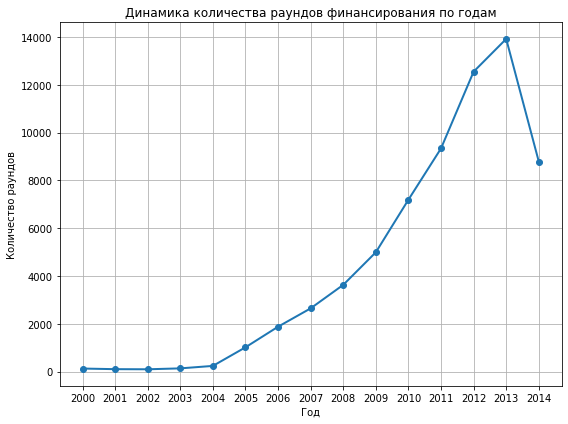

In [52]:
plt.figure(figsize=(8, 6))
rounds_by_year = df.groupby(df['mid_funding_at'].dt.year)['funding_rounds'].sum()

plt.plot(rounds_by_year.index, rounds_by_year.values, 
         marker='o', 
         linewidth=2 
         )
plt.title('Динамика количества раундов финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.grid()
plt.xticks(rounds_by_year.index)
plt.tight_layout()
plt.show()

В 2006 году типичный размер средств, собранных в рамках одного раунда, был максимальным.
В 2014 году идет резкий спад в размере раундов по сравнению с предыдущими годами, но наблюдается небольшой рост в финансировании.
Можно утверждать что объём среднего раунда инвестиции перестал падать.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составляем сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отбираем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отражаем, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматриваем только массовые сегменты.

In [53]:
actual_year = df['mid_funding_at'].dt.year
pivot = pd.pivot_table(
    df,
    values='funding_total_usd',
    index='market',
    columns=actual_year,
    aggfunc='sum'
)

display(pivot)

growth_segments = pivot[(pivot[2014] > pivot[2013])].index

print(f"Количество сегментов с ростом в 2014 году: {len(growth_segments)}")
print(f"Сегменты: {growth_segments}")

mid_funding_at,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,
advertising,50250000.0,14998321.0,NaN,17350000.0,112500000.0,1.547000e+08,3.269619e+08,5.427740e+08,8.508479e+08,1.014514e+09,1.147044e+09,1.517511e+09,1.047235e+09,7.548063e+08,2.713078e+08
analytics,1200000.0,10774916.0,7500000.0,NaN,3000000.0,8.221100e+07,1.869495e+08,9.707454e+07,4.576263e+08,3.497219e+08,5.639238e+08,6.467801e+08,1.102176e+09,1.046487e+09,3.809131e+08
apps,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.841060e+07,8.536842e+06,1.195000e+07,4.439268e+07,6.954230e+07,1.054791e+08,7.852251e+07,2.834894e+08
automotive,NaN,NaN,NaN,4530000.0,NaN,5.628258e+07,3.646000e+07,2.260000e+07,1.350834e+08,1.125231e+08,2.094701e+08,9.339982e+07,1.022481e+08,9.234774e+07,1.111559e+08
big_data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.100000e+06,1.150000e+06,3.579890e+06,5.874540e+07,6.777916e+07,2.619686e+08,1.683719e+08,2.073826e+08
biotechnology,NaN,NaN,NaN,25262631.0,122766544.0,4.096895e+08,1.017470e+09,1.120683e+09,1.248523e+09,3.156901e+09,5.060068e+09,6.891959e+09,6.886060e+09,5.558787e+09,3.310661e+09
clean_technology,NaN,NaN,NaN,NaN,NaN,2.159500e+07,2.032806e+08,4.066336e+08,2.105767e+09,1.240268e+09,2.106230e+09,1.743655e+09,1.406539e+09,1.213418e+09,6.793884e+08
cloud_computing,11500000.0,NaN,NaN,NaN,NaN,4.900000e+06,1.603546e+07,8.543430e+05,1.114800e+08,7.814856e+07,1.017461e+08,1.168531e+08,2.558664e+08,2.927676e+08,1.431409e+08
consulting,4500000.0,NaN,13500000.0,NaN,NaN,6.486200e+07,1.309655e+08,2.543921e+08,1.563191e+08,1.376573e+08,1.145908e+08,2.264746e+08,2.127096e+08,3.769743e+08,9.382804e+07


Количество сегментов с ростом в 2014 году: 16
Сегменты: Index(['apps', 'automotive', 'big_data', 'entertainment', 'internet',
       'manufacturing', 'medical', 'messaging', 'mid', 'niche', 'photography',
       'saas', 'sports', 'startups', 'technology', 'video'],
      dtype='object', name='market')


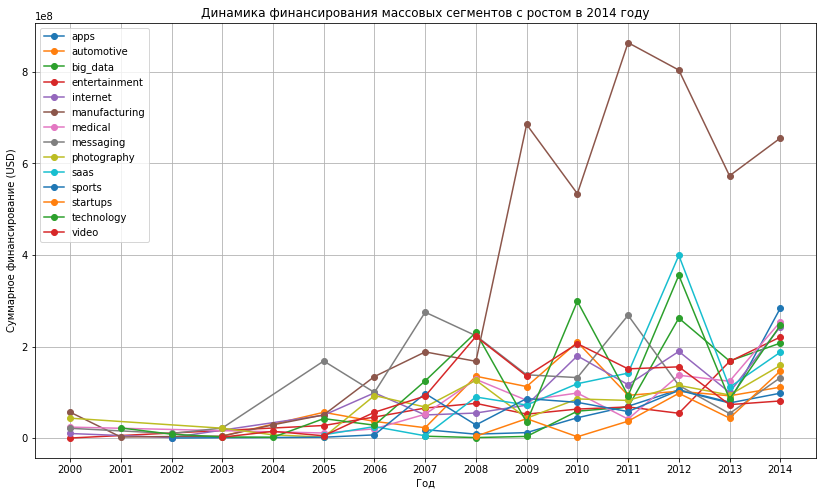

In [54]:
growth_segments = pivot[(pivot[2014] > pivot[2013])].index
mass_market = [market for market in growth_segments 
                if 'mid' not in str(market).lower() and 'niche' not in str(market).lower()]

plt.figure(figsize=(14, 8))

for segment in mass_market:
    if segment in pivot.index:
        segment_data = pivot.loc[segment]
        valid_years = segment_data[segment_data.notna()].index
        
        plt.plot(valid_years, segment_data[valid_years], 
                 marker='o', label=segment)

plt.title('Динамика финансирования массовых сегментов с ростом в 2014 году')
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование (USD)')
plt.legend()
plt.xticks(rounds_by_year.index)
plt.grid()
plt.show()

График показывает, что после 2008 года особенно сильно выросли инвестиции в сегменты manufacturing, тогда как остальные отрасли росли более умеренно и равномерно. Это указывает на смещение приоритетов инвесторов в сторону производства 
До 2013 года большинство сегментов рынка демонстрировали устойчивый рост инвестиций, а в 2013 году почти все сегменты рынка показали значительное снижение инвестиций (кроме Entertainment).


### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам,поэтому для каждого года и каждого вида финансирования рассчитываем нормированные значения возврата средств.

In [55]:
investment_columns = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                     'convertible_note', 'debt_financing', 'angel', 'grant', 
                     'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                     'secondary_market', 'product_crowdfunding']

actual_year = df['mid_funding_at'].dt.year
investment_by_year = df.groupby(actual_year)[investment_columns].sum() / 1000000
returns_by_year = re_df[investment_columns]

combined_data = investment_by_year.join(returns_by_year, how='inner', rsuffix='_return')

return_ratios = []

for col in investment_columns:
    investment_col = col
    return_col = col + '_return'
    
    ratio = combined_data[return_col] / (combined_data[investment_col] + 1e-60)
    
    Q1 = ratio.quantile(0.25)
    Q3 = ratio.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    ratio_clean = ratio.where((ratio >= lower_bound) & (ratio <= upper_bound))
    
    ratio_clean = ratio_clean.where((ratio_clean >= 0) & (ratio_clean <= 10))
    
    for year, value in ratio_clean.items():
        return_ratios.append({
            'investment_type': col,
            'year': year,
            'return_ratio': value
        })

return_ratios_long = pd.DataFrame(return_ratios)

return_ratios_wide = return_ratios_long.pivot(
    index='investment_type', 
    columns='year', 
    values='return_ratio'
)

return_ratios_percent = return_ratios_wide * 100

print("Доля возврата средств:")
display(return_ratios_percent.style.format('{:.2f}%'))

Доля возврата средств:


year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
investment_type,,,,,,,,,,,,,,,
angel,27.23%,111.96%,nan%,39.65%,101.40%,59.39%,78.44%,84.43%,42.37%,54.38%,44.07%,39.99%,32.87%,44.79%,89.01%
convertible_note,0.00%,nan%,nan%,nan%,0.15%,nan%,nan%,72.89%,11.97%,2.74%,8.01%,3.79%,4.15%,5.26%,5.71%
debt_financing,nan%,85.52%,nan%,25.06%,49.27%,87.76%,67.22%,48.09%,80.78%,37.34%,31.42%,29.35%,28.00%,40.07%,48.63%
equity_crowdfunding,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,nan%,nan%,3.22%,nan%,97.50%,4.91%,3.72%,1.66%,0.53%
grant,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
post_ipo_debt,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,nan%,nan%,nan%,13.61%
post_ipo_equity,nan%,nan%,113.33%,nan%,nan%,nan%,593.47%,nan%,521.66%,75.38%,151.47%,56.02%,41.30%,51.57%,15.96%
private_equity,0.00%,0.00%,3.25%,nan%,5.92%,nan%,8.75%,103.45%,67.11%,64.08%,35.79%,46.96%,39.16%,41.61%,29.50%
product_crowdfunding,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,nan%,nan%,nan%,0.88%,0.35%,0.52%


Строим график, на котором отображаем нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

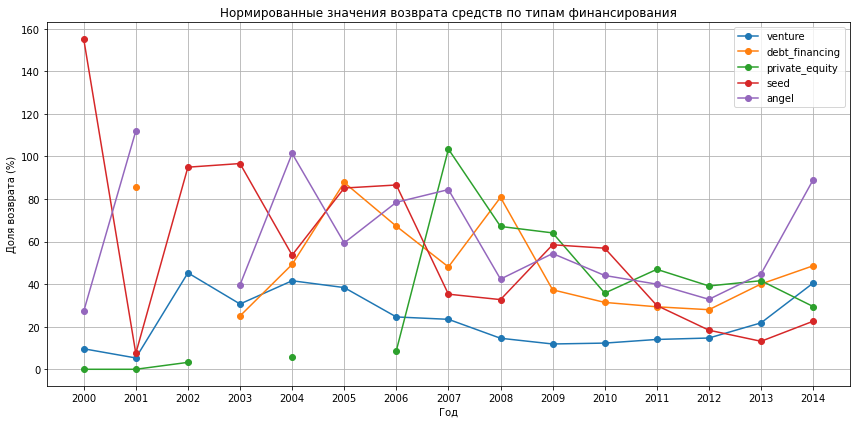

In [56]:
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

plt.figure(figsize=(12, 6))

for investment_type in selected_types:
    if investment_type in return_ratios_percent.index:
        data = return_ratios_percent.loc[investment_type]
        years = data.index
        values = data[years]
        plt.plot(years, 
                 values,
                 marker='o',
                 label=investment_type)

plt.title('Нормированные значения возврата средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возврата (%)')
plt.legend()
plt.xticks(rounds_by_year.index)
plt.grid()
plt.tight_layout()
plt.show()

Ни у одного типа финансирования нет стабильного роста: 
 - венчурные инвестиций: стабильно небольшие показатели, в основном 10-40% возврата
 - долговые финансирования: большинство значений в диапазоне 30-8,%, в целом хорошие показатели
 - частные вложения:с 2007 года идет на спад
 - посевные инвестиций: показывает большой разброс
 - бизнес-ангелы: показывает большой разброс


## Шаг 5. Итоговый вывод и рекомендации

В ходе исследования проанализировали данные  о стартапах, объёмах и типах финансирования, а также статистику возвратов средств для финансовой компании, работающей с венчурными инвестициями.

Вывели информацию, которая необходима для принятия решений о предобработке, для каждого из датасетов. Было обнаружено большое количество пропусков в одном из датасетов, несоответствие типов данных. Пропуски были удалены по минимуму, дабы избежать искажения анализа. Данные проверили на явные и неявные дубликаты — после удаления сохранено 40906 записи, что составляет 75% от исходного объема данных. Обработали типы данных в столбцах, которые хранят значения даты и времени.

Добавлены новые поля для анализа: 
Были созданы столбцы: group_funding_at - разделение всех компании на группы по срокам финансирования и avg_round_amount - средний объём одного раунда финансирования.

Использованы методы статистического анализа и визуализация данных.
- Разделили компании на группы по длительности финансирования, посчитали распределение по количеству компаний в каждой группе, проанализировали долю от общего объема инвестиций, построили два графика: по количеству компаний и по объему инвестиций
- Выделили средние и нишевые сегменты рынка: Посчитали сколько компаний в каждом сегменте,  разделили на три категории, посчитали количество сегментов в каждой категории
- Проанализированы и помечаны выбросы в каждом из сегментов
- Определены компании с аномальным объёмом общего финансирования, использован метод IQR отдельно по каждому сегменту. Определены сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведен топ таких сегментов.
- Определили границы рассматриваемого периода, исключили из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.
- Проанализированы типы финансирования по объёму и популярности:  Построен график общего объема привлеченных средств по каждому типу финансирования и график популярности - сколько раз каждый тип финансирования встречается в датасете, а так же график суммарных объёмов возвратов от разных типов финансирования
- Выполнен расчет и анализ раундов финансирования: рассчитан средний объем одного раунда, построены графики динамики
- Выполнен анализ динамики финансирования по массовым сегментам: создана сводная таблица с суммарным размером финансирования по годам и сегментам рынка, отобраны растущие сегменты, построен график динамики
- Выполнен анализ годовой динамики доли возвращённых средств: рассчитаны нормированные значения возврата для каждого года и типа финансирования, определена доля возвращённых средств от предоставленных по формуле, обработаны аномальные значения (неадекватные выбросы заменены на пропуски)

1. Как компании привлекают финансирование:
- Больше половины стартапов выбирают разовое финансирование
- Треть компаний предпочитает долгосрочное финансирование - это самые крупные сделки
2. Структура рынков:
- Большинство сегментов являются нишевыми (71%)
- Массовые сегменты составляют всего 12%, но концентрируют основные компании
3. Эффективность инвестиций:
- Венчурные инвестиции приносят больше всего возвратов (74%)
- Долговое финансирование показывает стабильно высокие результаты
- Частные вложения демонстрируют умеренную доходность
- Ангельские инвестиции дают самые высокие возвраты, но с большими рисками
- Гранты являются единственным бесприбыльным инструментом

Рекомендация: для надежных вложений лучше выбирать венчурные и долговые инструменты, избегая крайне рискованных вариантов.
